DECISION TREE IN PYTHON

Esempi di regressione e classificazione tramite decisoin tree 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_wine
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree


CLASSIFICAZIONE (wine)

In [5]:
wine=load_wine()
X_wine,y_wine=wine.data,wine.target
print(X_wine[:5])
print(y_wine[:5])

[[1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
  2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 1.120e+01 1.000e+02 2.650e+00 2.760e+00
  2.600e-01 1.280e+00 4.380e+00 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 1.860e+01 1.010e+02 2.800e+00 3.240e+00
  3.000e-01 2.810e+00 5.680e+00 1.030e+00 3.170e+00 1.185e+03]
 [1.437e+01 1.950e+00 2.500e+00 1.680e+01 1.130e+02 3.850e+00 3.490e+00
  2.400e-01 2.180e+00 7.800e+00 8.600e-01 3.450e+00 1.480e+03]
 [1.324e+01 2.590e+00 2.870e+00 2.100e+01 1.180e+02 2.800e+00 2.690e+00
  3.900e-01 1.820e+00 4.320e+00 1.040e+00 2.930e+00 7.350e+02]]
[0 0 0 0 0]


addestramento modello

In [8]:
dt_classifier=DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)
dt_classifier.fit(X_wine,y_wine) #addestramento su X_win
y_pred_class=dt_classifier.predict(X_wine) #predizone su X_win con le stesse righe di addestramento


In [12]:
print(f"Prodondita: {dt_classifier.get_depth()}")
print(f"numero foglie: {dt_classifier.get_n_leaves()}")

Prodondita: 3
numero foglie: 8


visualizzazione (plot)

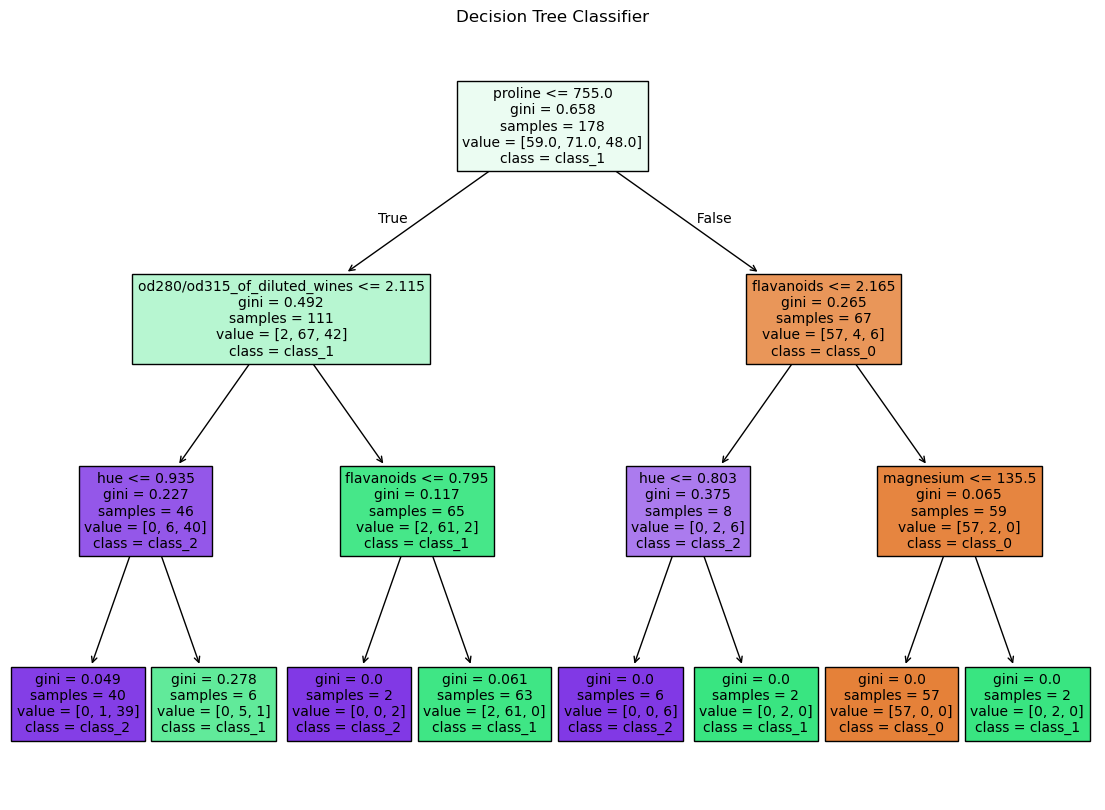

In [16]:
plt.figure(figsize=(14,10))
plot_tree(
    dt_classifier,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True,
    fontsize=10,
)
plt.title("Decision Tree Classifier")
plt.show()

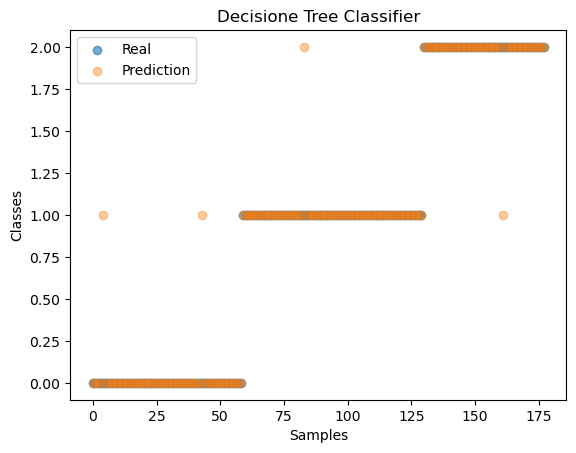

In [17]:
plt.Figure(figsize=(6,6))
plt.scatter(range(len(y_wine)),y_wine,label="Real",alpha=0.6)
plt.scatter(range(len(y_wine)),y_pred_class,label="Prediction",alpha=0.4)
plt.title("Decisione Tree Classifier")
plt.xlabel("Samples")
plt.ylabel("Classes")
plt.legend()
plt.show()

In [26]:
classification_accuracy=(y_pred_class==y_wine).sum()/len(y_wine) #etichette corrette su etichette totali
print(f"Accuracy Classification: {round(classification_accuracy * 100, 2)}%({classification_accuracy})")

Accuracy Classification: 97.75%(0.9775280898876404)


REGRESSIONE (california housing)

In [27]:
cali=fetch_california_housing()
X_cali,y_cali=cali.data, cali.target

Creazione modello

In [28]:
dt_regressor=DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)
dt_regressor.fit(X_cali,y_cali)
y_pred_regr=dt_regressor.predict(X_cali)

In [29]:
print(f"Prodondita: {dt_regressor.get_depth()}")
print(f"numero foglie: {dt_regressor.get_n_leaves()}")

Prodondita: 3
numero foglie: 8


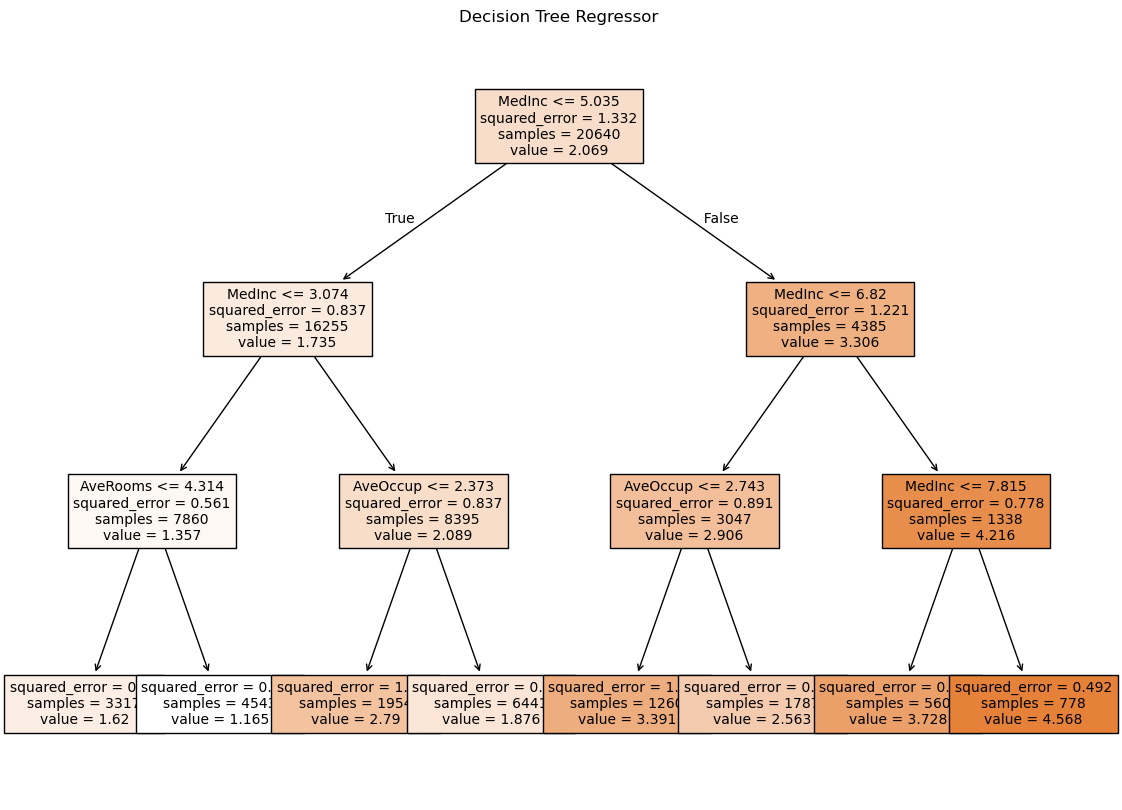

In [30]:
plt.figure(figsize=(14,10))
plot_tree(
    dt_regressor,
    feature_names=cali.feature_names,
    class_names=cali.target_names,
    filled=True,
    fontsize=10,
)
plt.title("Decision Tree Regressor")
plt.show()

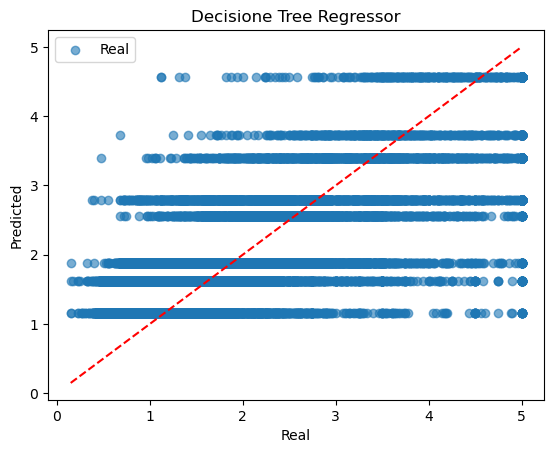

In [33]:
plt.Figure(figsize=(6,6))
plt.scatter(y_cali,y_pred_regr,label="Real",alpha=0.6)
plt.plot([y_cali.min(),y_cali.max()],[y_cali.min(),y_cali.max()],'r--')
plt.title("Decisione Tree Regressor")
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.legend()
plt.show()

In [35]:
tols = [0.01, 0.1, 0.5, 1]
for tol in tols:
    regr_acc = (abs(y_pred_regr - y_cali) < tol).sum() / len(y_cali)
    print(f"Regression Accuracy ({tol = }):\t{round(regr_acc * 100, 2)}%\t({regr_acc})")

Regression Accuracy (tol = 0.01):	1.31%	(0.01308139534883721)
Regression Accuracy (tol = 0.1):	11.59%	(0.11593992248062016)
Regression Accuracy (tol = 0.5):	54.66%	(0.5465600775193798)
Regression Accuracy (tol = 1):	83.63%	(0.8362887596899224)
